In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df = pd.read_excel('Dataset 2021.xlsx')
display(pd.DataFrame(df))

,Year,Crime Type,Crime Head,Total # FIR,Total # Final Report,FR Non-Cognizable,FR False,Mistake of Fact / Law / Civil Dispute,True but insufficient evidence,Cases Abated,...,Cases Abated by Court,Cases Withdrawn from Prosecution,Cases Compounded or Compromised,Cases Disposed Off by Plea Bargaining,Cases Quashed,Cases Convicted,Cases Discharged,Cases Acquitted,Cases Where Trials Were Completed,Total # Cases Disposed Off by Courts
0,2021,SLL,Prohibition Act,678998,5644,6,80,145,5088,325,...,1084,41,487,0,2,195616,19128,104256,319000,320614
1,2021,IPC,Theft,586649,409819,950,6248,48011,353994,616,...,347,315,18528,560,77,20714,4021,26509,51244,71071
2,2021,IPC,Hurt,585774,69671,3554,15667,25129,24634,687,...,729,224,40123,7790,407,54707,11925,80965,147597,196870
3,2021,IPC,Rash Driving on Public Way,347953,31157,32,2533,5337,22867,388,...,573,211,12288,612,88,167117,4119,318880,203116,216888
4,2021,SLL,Excise Act,335699,2245,2,337,241,1623,42,...,231,28,589,62,55,182062,1016,14387,197465,198430
5,2021,SLL,Electricity Act,138513,17625,679,224,2649,11661,2412,...,1191,1,53372,523,126,16607,1996,3377,21980,77193
6,2021,IPC,"Forgery, Cheating and Fraud",152073,69045,450,14193,19264,34571,567,...,277,32,3573,218,183,4577,800,10457,15834,20117
7,2021,SLL,Gambling Act,164324,274,0,10,36,188,40,...,186,14,211,1,57,109273,4873,14865,129011,129480
8,2021,IPC,Causing Death by Negligence,146195,35725,234,1507,3532,23661,6791,...,1805,7,572,214,174,13503,2630,21311,37444,40216
9,2021,IPC,Criminal Intimidation,123442,11357,114,2100,2594,6508,41,...,86,12,5552,2147,33,8539,983,16936,26458,34288


In [ ]:
df.columns

Index(['Year', 'Crime Type', 'Crime Head', 'Total # FIR',
       'Total # Final Report', 'FR Non-Cognizable', 'FR False',
       'Mistake of Fact / Law / Civil Dispute',
       'True but insufficient evidence', 'Cases Abated',
       'Total # Charge Sheeted', 'Total # Cases Disposed Off by Police',
       '# Cases sent for Trial', 'Cases Disposed Off Without Trial',
       'Cases Abated by Court', 'Cases Withdrawn from Prosecution',
       'Cases Compounded or Compromised',
       'Cases Disposed Off by Plea Bargaining', 'Cases Quashed',
       'Cases Convicted', 'Cases Discharged', 'Cases Acquitted',
       'Cases Where Trials Were Completed',
       'Total # Cases Disposed Off by Courts'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Year                                   20 non-null     int64 
 1   Crime Type                             20 non-null     object
 2   Crime Head                             20 non-null     object
 3   Total # FIR                            20 non-null     int64 
 4   Total # Final Report                   20 non-null     int64 
 5   FR Non-Cognizable                      20 non-null     int64 
 6   FR False                               20 non-null     int64 
 7   Mistake of Fact / Law / Civil Dispute  20 non-null     int64 
 8   True but insufficient evidence         20 non-null     int64 
 9   Cases Abated                           20 non-null     int64 
 10  Total # Charge Sheeted                 20 non-null     int64 
 11  Total # Cases Dispose

### **Schema Validation**
* **Data Types:** 22 numerical features (`int64`) and 2 categorical identifiers (`Crime Type`, `Crime Head`).
* **Data Integrity:** All 20 entries are fully populated across all columns. No explicit data type conversions are required for numeric metrics.

In [ ]:
df.describe()

,Year,Total # FIR,Total # Final Report,FR Non-Cognizable,FR False,Mistake of Fact / Law / Civil Dispute,True but insufficient evidence,Cases Abated,Total # Charge Sheeted,Total # Cases Disposed Off by Police,...,Cases Abated by Court,Cases Withdrawn from Prosecution,Cases Compounded or Compromised,Cases Disposed Off by Plea Bargaining,Cases Quashed,Cases Convicted,Cases Discharged,Cases Acquitted,Cases Where Trials Were Completed,Total # Cases Disposed Off by Courts
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,...,20.000000,20.00000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2021.0,215350.300000,41997.400000,505.150000,3856.600000,8340.900000,28645.850000,648.90000,172440.450000,214829.300000,...,386.200000,710.85000,7873.65000,731.350000,487.050000,55518.050000,4237.850000,38337.050000,83742.950000,93932.050000
std,0.0,196003.543251,89967.316036,1018.270581,5572.817131,12702.859727,77823.684119,1542.63305,173720.707021,195883.081139,...,470.340705,2905.63877,14315.16732,1745.820883,1703.643849,67942.453795,6537.932711,72276.665285,94466.779336,98241.460815
min,2021.0,35089.000000,53.000000,0.000000,3.000000,5.000000,43.000000,1.00000,34772.000000,34825.000000,...,30.000000,1.00000,30.00000,0.000000,0.000000,2665.000000,557.000000,2389.000000,9084.000000,9598.000000
25%,2021.0,86482.750000,1993.750000,3.500000,104.000000,144.250000,1027.000000,40.75000,68164.250000,87740.750000,...,125.250000,13.50000,443.50000,11.250000,9.000000,6338.000000,937.250000,5683.000000,21638.250000,26436.500000
50%,2021.0,137373.500000,16233.000000,79.000000,1170.000000,3090.500000,5798.000000,120.50000,97564.500000,129732.500000,...,178.500000,24.00000,1026.00000,178.000000,56.000000,20730.500000,1154.500000,13721.500000,35887.000000,45854.500000
75%,2021.0,325511.000000,41023.250000,360.750000,6377.000000,9610.500000,23065.500000,445.50000,201106.500000,346060.500000,...,403.500000,78.00000,6815.25000,573.000000,164.250000,68348.500000,4045.500000,22610.500000,133657.500000,146327.500000
max,2021.0,678998.000000,409819.000000,3554.000000,17050.000000,48011.000000,353994.000000,6791.00000,647233.000000,653306.000000,...,1805.000000,13050.00000,53372.00000,7790.000000,7697.000000,195616.000000,24114.000000,318880.000000,319000.000000,320614.000000


### **Descriptive Statistics & Skewness**
* **High Variance:** Significant dispersion across crime heads (e.g., `Total # FIR` ranges from a minimum of 35,089 to a maximum of 678,998).
* **Right Skewness:** The mean FIR count (215,350) is substantially higher than the median (137,373), indicating that a few high-volume crime heads heavily drive the overall statistics.

In [ ]:
[features for features in df.columns if df[features].isnull().sum()>0]

[]

### **Data Completeness**
* **Zero Missing Values:** The null check returned an empty list `[]`. No imputation techniques (mean/median/KNN) are required.

In [ ]:
charge_sheeted = df['Total # Charge Sheeted'].value_counts().index
charge_sheeted = charge_sheeted.sort_values(ascending=False)

state_charge_sheet_counts = df.groupby('Crime Head')['Total # Charge Sheeted'].sum()
sorted_states = state_charge_sheet_counts.sort_values(ascending=False)
print(sorted_states)
s = sorted_states.index

Crime Head
Prohibition Act                                             647233
Hurt                                                        526994
Disobedience to order duly promulgated by Public Servant    354645
Excise Act                                                  341961
Rash Driving on Public Way                                  315273
Gambling Act                                                163051
Theft                                                       159446
Cruelty by husband or his relatives                         114304
Criminal Intimidation                                       112655
Causing Death by Negligence                                 111476
Electricity Act                                              83653
Assault on Women with intent to outrage her modesty          77168
Forgery, Cheating and Fraud                                  73932
Arms Act                                                     73511
Narcotic Drugs and Psychotropic Substances Act     

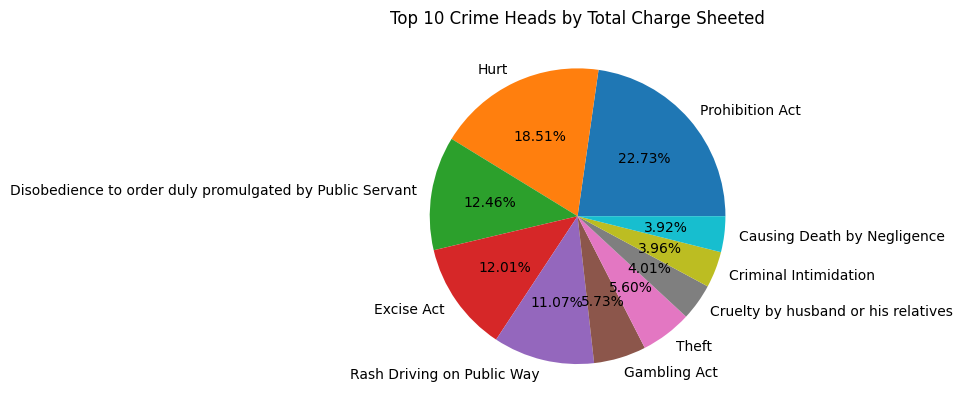

In [ ]:
plt.pie(charge_sheeted[:10],labels=s[:10],autopct='%1.2f%%')
plt.title('Top 10 Crime Heads by Total Charge Sheeted')
plt.show()

### **High-Volume Crime Heads**
* **Top Drivers:** *Prohibition Act* (647,233) and *Hurt* (526,994) account for the highest volume of charge-sheeted cases.
* **Concentration:** The top 10 crime categories represent the vast majority of all formal prosecutions filed in 2021.

In [ ]:
Crime_report_counts = df.groupby(['Crime Head','Total # FIR','Total # Charge Sheeted']).size()
print(Crime_report_counts)

Crime Head                                                Total # FIR  Total # Charge Sheeted
Arms Act                                                  74482        73511                     1
Assault on Women with intent to outrage her modesty       89200        77168                     1
Burglary                                                  97792        39788                     1
Causing Death by Negligence                               146195       111476                    1
Criminal Intimidation                                     123442       112655                    1
Cruelty by husband or his relatives                       136234       114304                    1
Disobedience to order duly promulgated by Public Servant  322115       354645                    1
Electricity Act                                           138513       83653                     1
Excise Act                                                335699       341961                    1
Forgery, Cheati

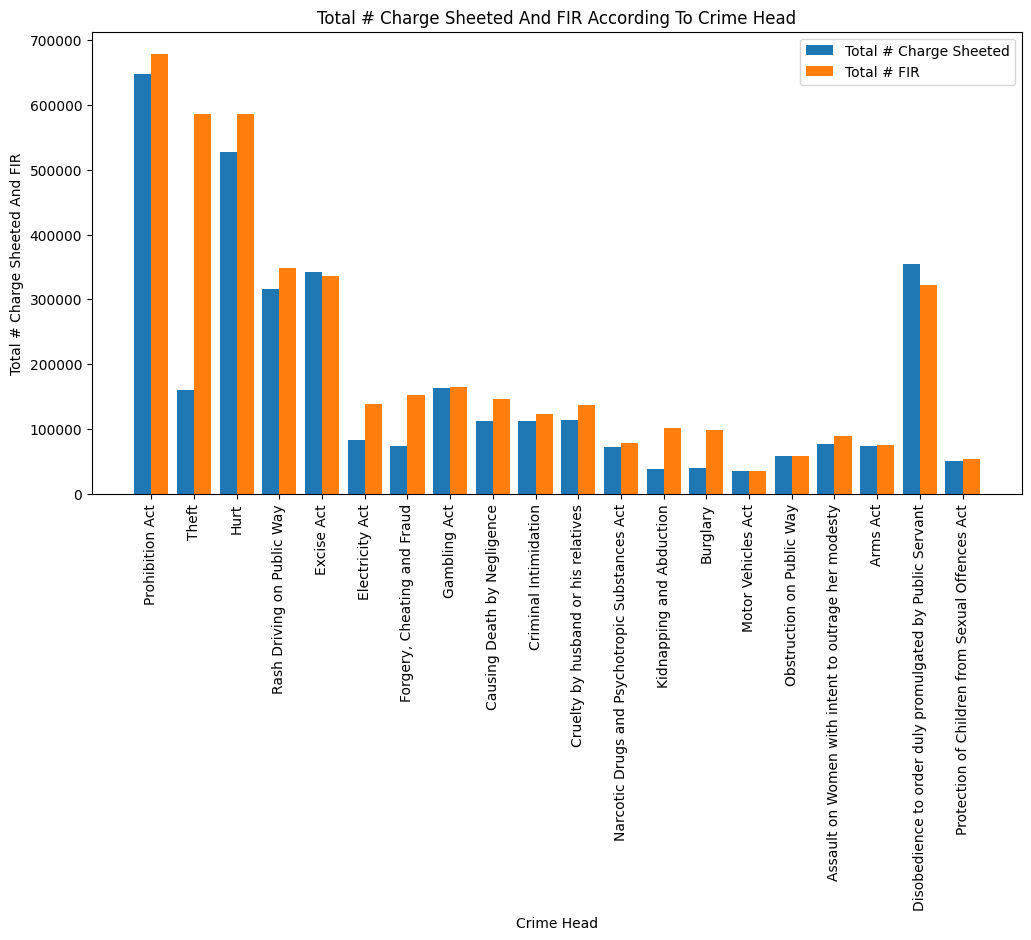

In [ ]:
C_S = df['Total # Charge Sheeted'].value_counts().index
C_H = df['Crime Head'].value_counts().index
C_FIR = df['Total # FIR'].value_counts().index
width = 0.4
plt.figure(figsize=(12, 6))
p = np.arange(len(C_H))
p1 = [j+width for j in p]
plt.xlabel('Crime Head')
plt.ylabel('Total # Charge Sheeted And FIR')
plt.bar(p,C_S,width=width,label='Total # Charge Sheeted')
plt.bar(p1,C_FIR,width=width,label='Total # FIR')
plt.xticks(p+width/2,C_H,rotation=90)
plt.title('Total # Charge Sheeted And FIR According To Crime Head')
plt.legend(loc='best')
plt.show()

### **Comparative Analysis (Reports vs. Prosecution)**
* **High Conversion Offenses:** Regulatory/state offenses (e.g., *Prohibition Act*, *Disobedience*) show near 1:1 conversion from FIRs to Charge Sheets.
* **Low Conversion Offenses:** Property crimes like *Theft* exhibit a substantial gap between FIRs (586k) and Charge Sheets (159k), owing to a higher volume of unresolved final reports.

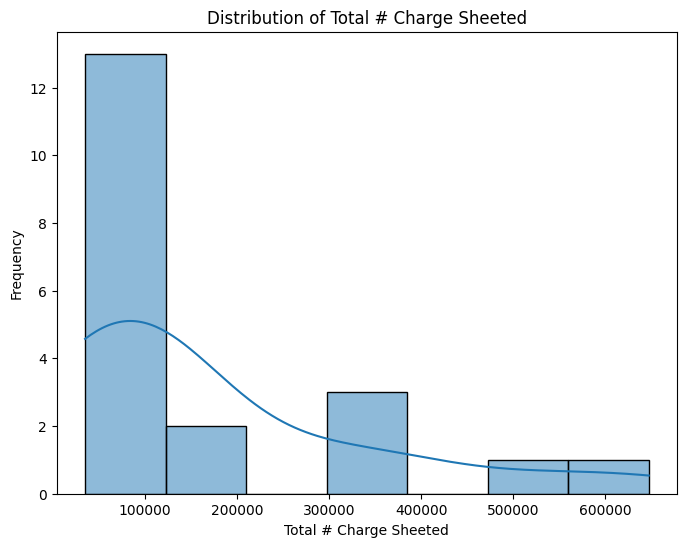

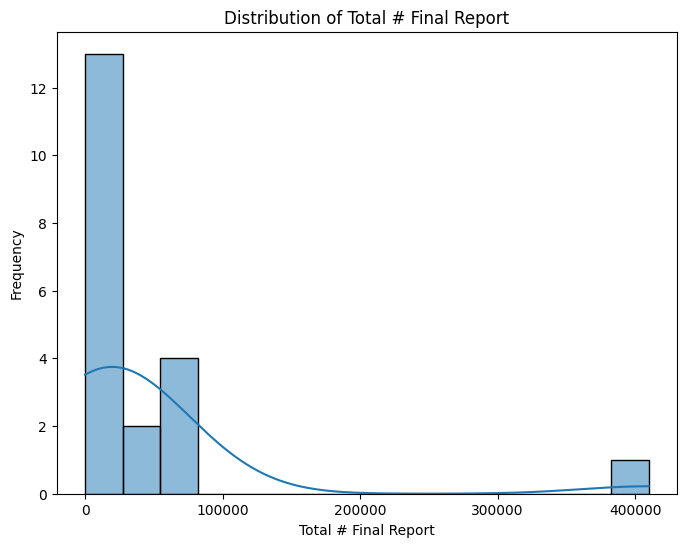

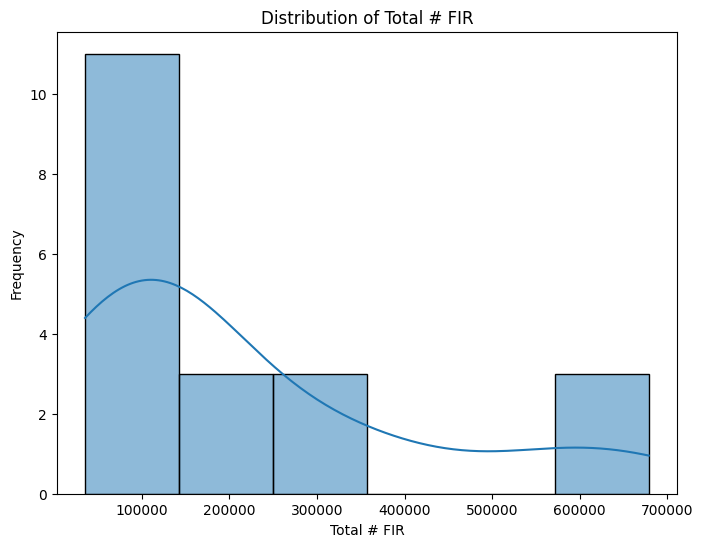

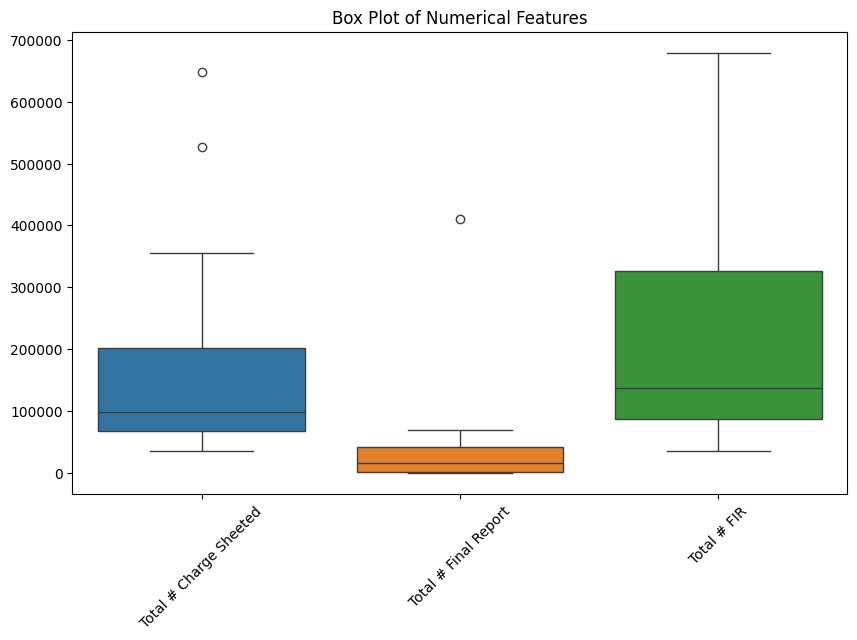

In [ ]:
# Select numerical features
numerical_features = ['Total # Charge Sheeted', 'Total # Final Report', 'Total # FIR']

# Create histograms
for feature in numerical_features:
  plt.figure(figsize=(8, 6))  # Adjust figure size if needed
  sns.histplot(df[feature], kde=True)  # kde=True adds a kernel density estimate
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')
  plt.show()

# Create box plots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_features])
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

### **Distribution & Outlier Analysis**
* **Non-Normal Distributions:** Histograms and KDE curves confirm positive (right) skewness across all core numeric metrics.
* **Outlier Presence:** Box plots confirm extreme upper-bound outliers corresponding to dominant crime heads. Log-transformation or robust scaling is recommended prior to machine learning.

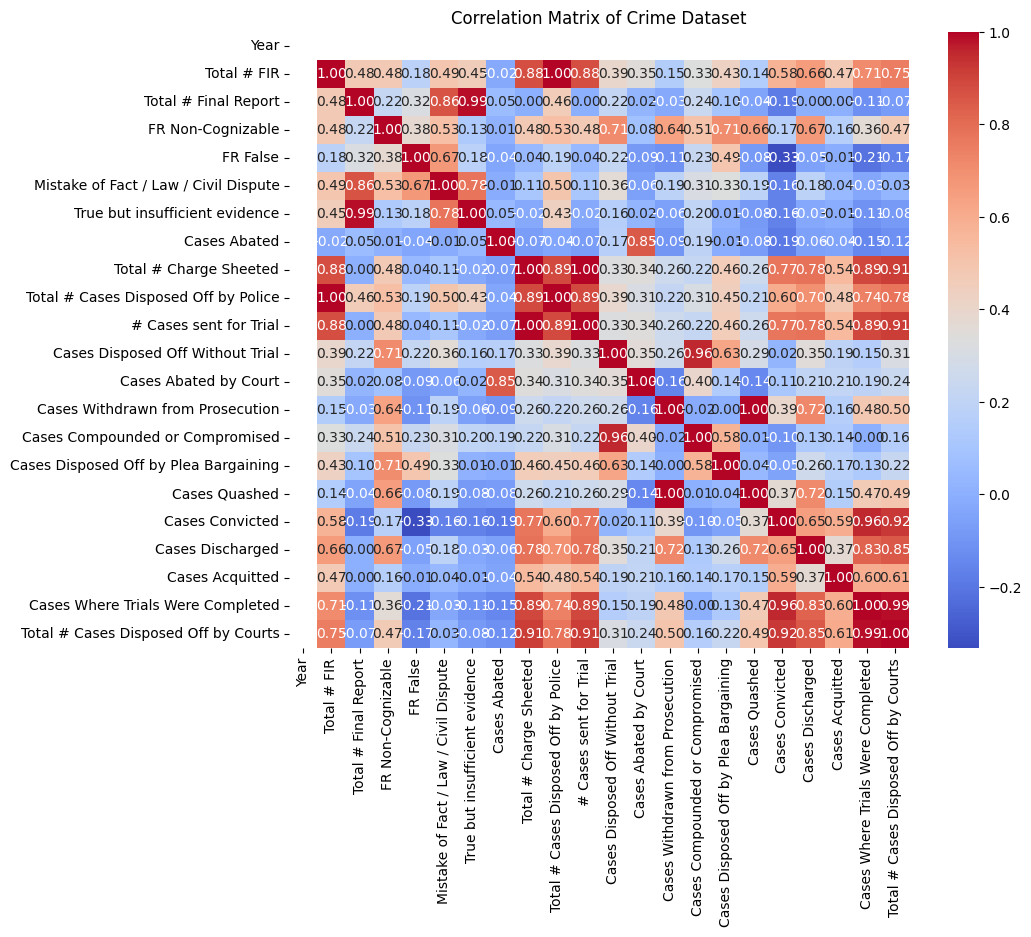

In [ ]:
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['number'])  # Filter out non-numerical columns

# Calculate correlation matrix using the numerical DataFrame
correlation_matrix = numerical_df.corr()

# Visualize correlation matrix using a heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Crime Dataset')
plt.show()

In [ ]:
correlation = df['Total # Charge Sheeted'].corr(df['Total # FIR'])
print(f"Correlation between Total # Charge Sheeted and Total # FIR: {correlation}")

Correlation between Total # Charge Sheeted and Total # FIR: 0.8752617970239721


### **Correlation & Multicollinearity**

**1.Strong Positive Correlation between 'Total # Charge Sheeted' and 'Total # FIR':**

The heatmap shows a correlation coefficient of approximately 0.88 between 'Total # Charge Sheeted' and 'Total # FIR'. This indicates a strong positive linear relationship between these two variables. This means that as the total number of charge sheets filed increases, the total number of FIRs (First Information Reports) registered also tends to increase.

**2.Moderate Positive Correlation between 'Total # Charge Sheeted' and 'Total # Final Report':**

There's a correlation coefficient of around 0.62 between 'Total # Charge Sheeted' and 'Total # Final Report'. This suggests a moderate positive linear relationship, meaning that as the number of charge sheets increases, the number of final reports filed also tends to increase, but the relationship is not as strong as with 'Total # FIR'.

**3.Moderate Positive Correlation between 'Total # FIR' and 'Total # Final Report':**

A correlation coefficient of about 0.66 is observed between 'Total # FIR' and 'Total # Final Report'. This indicates a moderate positive linear relationship, implying that as the number of FIRs increases, the number of final reports filed also tends to increase.


 **Strong Linear Co-movement ($r = 0.88$):** A strong positive correlation exists between `Total # FIR` and `Total # Charge Sheeted`.

 **Multicollinearity:** Primary count metrics share high mutual correlation. Dimensionality reduction (e.g., PCA) or feature selection should be considered before training linear regression models.

# **Conclusions:**

Relationship between Charge Sheets, FIRs, and Final Reports: There's a clear positive correlation between the number of charge sheets filed, FIRs registered, and final reports submitted. This suggests that these three aspects of the criminal justice system are interconnected and tend to move in the same direction. Strongest Relationship: The strongest positive correlation is between 'Total # Charge Sheeted' and 'Total # FIR', indicating a close relationship between these two stages of a criminal case. Moderate Relationships: The relationships between 'Total # Charge Sheeted' and 'Total # Final Report', and between 'Total # FIR' and 'Total # Final Report', are moderately positive, suggesting a less direct but still significant connection.**bold text**

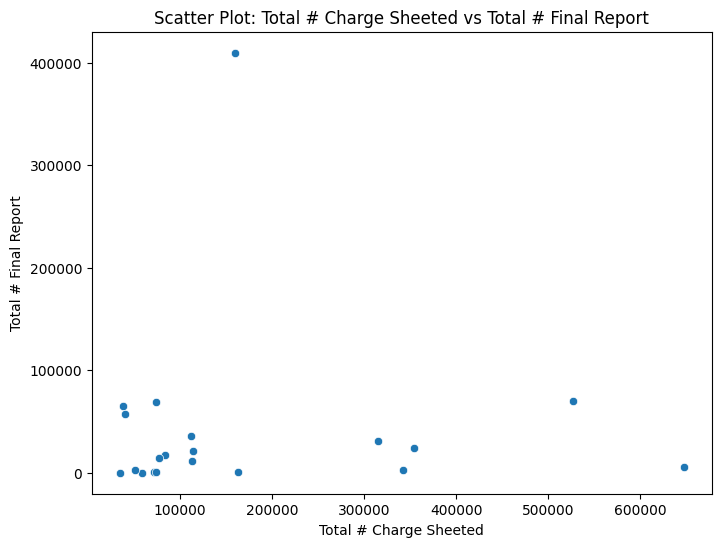

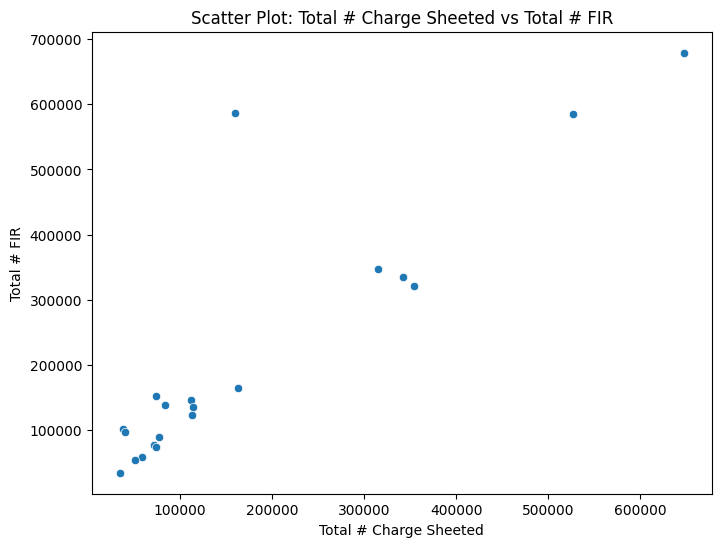

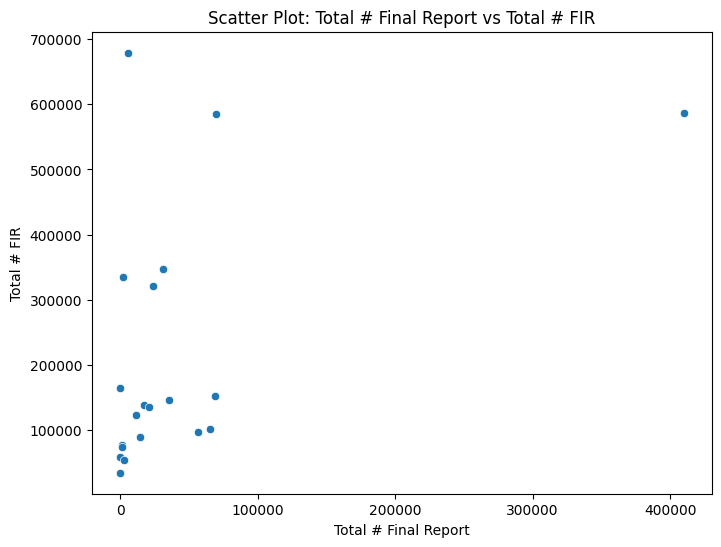

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features for scatter plots
numerical_features = ['Total # Charge Sheeted', 'Total # Final Report', 'Total # FIR']

# Create scatter plots for all pairs of features
for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):
        feature1 = numerical_features[i]
        feature2 = numerical_features[j]

        plt.figure(figsize=(8, 6))  # Adjust figure size if needed
        sns.scatterplot(x=df[feature1], y=df[feature2])
        plt.title(f'Scatter Plot: {feature1} vs {feature2}')
        plt.xlabel(feature1)
        plt.ylabel(feature2)
        plt.show()

### **Pairwise Interaction Analysis**
* Scatter plots confirm a clear linear trend between initial crime registration (`FIR`) and formal prosecution (`Charge Sheeted`).
* Relationships involving `Total # Final Report` show clustering near lower bounds, reinforcing that final reports are heavily concentrated in specific crime heads like *Theft*.

## **Overall EDA Summary & Executive Conclusion**

### **1. Data Integrity & Quality**
* **Completeness:** The 2021 Crime Dataset contains 20 core crime heads evaluated across 24 administrative and legal metrics with **0% missing values**.
* **Data Types:** All analytical metrics are cleanly formatted as 64-bit integers (`int64`), requiring no immediate type conversions.

---

### **2. Crime Volume & Distribution Patterns**
* **Dominant Offenses:** Case volume is heavily concentrated in specific crime heads. **Prohibition Act** (647k charge sheets) and **Hurt** (527k charge sheets) are the single largest drivers of formal prosecutions.
* **Severe Right Skewness:** Mean counts across all key metrics substantially exceed median values (e.g., Mean FIR 215k vs. Median 137k), confirming that total crime volume is skewed by a few extremely high-frequency crime heads.

---

### **3. Operational & Judicial Conversion Dynamics**
* **High Conversion Rate (Regulatory Offenses):** State-enforced regulatory crimes (such as *Prohibition Act*, *Excise Act*, and *Disobedience*) show a near 1:1 conversion rate from initial registration (`Total # FIR`) to court prosecution (`Total # Charge Sheeted`).
* **Low Conversion Rate (Property Crimes):** Property and theft crimes exhibit a wide prosecution gap. For example, **Theft** registered over 586k FIRs but only 159k Charge Sheets, resulting in over 409k cases closed via `Final Report` due to insufficient evidence or untraceable perpetrators.

---

### **4. Machine Learning & Modeling Recommendations**
* **Multicollinearity:** Count metrics display high linear co-movement, notably between `Total # FIR` and `Total # Charge Sheeted` ($r \approx 0.88$). Dimensionality reduction (e.g., PCA) or feature selection is required before fitting linear models.
* **Feature Scaling:** Due to extreme upper-bound outliers across high-volume categories, raw counts should be transformed using log scaling (`np.log1p`) or robust scaling prior to downstream modeling or clustering.